[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/okumura-kobe/kobe-data-business/blob/main/lecture01/lecture1_notebook_v3.ipynb)

# 後期大学院演習「データで動かす社会とビジネス」
## 第1回　演習 Notebook

**ケース：Capital Bikeshare 需要分析と運営判断**

---

### データの出典

| | |
|---|---|
| 出典 | UCI Machine Learning Repository, Bike Sharing Dataset |
| 対象 | Capital Bikeshare, Washington D.C. |
| 期間 | 2011–2012年 |
| 数 | 17,379時間分の観測値 |
| 著者 | Fanaee-T (2013) |
| ライセンス | CC BY 4.0 |

---

### この演習の進め方

- `____` の部分を自分で考えて埋めてください
- 各分析の後に **「何が言えるか」をMarkdownセルに書いてください**
- コードを書く → エラーが出る → 直す、この繰り返しが学習の核心です

---

| | |
|---|---|
| 学籍番号 | |
| 氏名 | |
| 実施日 | |

---
## Step 0　準備：ライブラリの読み込み

このセルは変更不要です。最初に実行してください。

In [1]:
# ライブラリの読み込み（変更不要）
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import zipfile, io, urllib.request, warnings

# 警告を非表示にする
warnings.filterwarnings('ignore')

# DataFrameの表示設定
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

# グラフのスタイル設定
# ※ グラフのラベルはすべて英語で記載（日本語フォント不要）
matplotlib.rcParams['axes.spines.top']   = False
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['figure.figsize']    = (11, 4)

print('Ready')

Ready


---
## Step 1　データを読み込む

### 変数の説明

| 変数名 | 説明 | 単位・備考 |
|---|---|---|
| `dteday` | 日付 | |
| `hr` | 時間帯 | 0〜23 |
| `season` | 季節 | 1=春 2=夏 3=秋 4=冬 |
| `workingday` | 平日フラグ | 1=平日 0=休日・祝日 |
| `weathersit` | 天候 | 1=晴 2=曇 3=小雨・霧 4=大雨・雪 |
| `temp` | 気温（正規化） | 0〜1（実際の気温÷41℃） |
| `hum` | 湿度（正規化） | 0〜1 |
| `casual` | カジュアルユーザー利用数 | 非登録者 |
| `registered` | 登録ユーザー利用数 | 会員 |
| `cnt` | 総利用数 | casual + registered |

---

⚠️ **コードを書く前に考えてください**

あなたはCapital Bikeshareの運営企画担当です。
このデータを使って**何を明らかにしたいか**、一言で書いてください。

In [ ]:
# 分析前の問いを書く（コメントとして）
#
# 私がこのデータから明らかにしたいことは：どうすればカジュアルユーザーを登録ユーザーに上げられるか
#つまり登録ユーザーとカジュアルユーザーにおける利用タイミングおよび頻度の違い
#

In [2]:
# データの読み込み
# GitHubリポジトリからbike.csvを直接読み込みます

import pandas as pd

url = "https://raw.githubusercontent.com/okumura-kobe/kobe-data-business/main/data/bike.csv"
df = pd.read_csv(url)

print(f'Rows: {df.shape[0]:,}  Cols: {df.shape[1]}')
print(f'Missing: {df.isnull().sum().sum()}')

Rows: 17,379  Cols: 17
Missing: 0


In [3]:
# 1-1　最初の数行を確認する
# TODO: 最初の5行を表示してください

#df.____
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.240,0.288,0.810,0.000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.220,0.273,0.800,0.000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.220,0.273,0.800,0.000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.240,0.288,0.750,0.000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.240,0.288,0.750,0.000,0,1,1


In [4]:
# 1-2　列の情報を確認する
# TODO: 列名・型・欠損数を確認してください

#df.____
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
# 1-3　基本統計量を確認する
# TODO: 数値変数の要約統計量を表示してください

#df[['casual', 'registered', 'cnt', 'temp', 'hum']].____
df[['casual', 'registered', 'cnt', 'temp', 'hum']].describe()

,casual,registered,cnt,temp,hum
count,17379.000,17379.000,17379.000,17379.000,17379.000
mean,35.676,153.787,189.463,0.497,0.627
std,49.305,151.357,181.388,0.193,0.193
min,0.000,0.000,1.000,0.020,0.000
25%,4.000,34.000,40.000,0.340,0.480
50%,17.000,115.000,142.000,0.500,0.630
75%,48.000,220.000,281.000,0.660,0.780
max,367.000,886.000,977.000,1.000,1.000


**📝 Step 1 の気づき（ここに書いてください）**

- データの特徴として気づいたこと：
- 気になった変数や値：
- 疑問点：

---
## 分析①　時間帯別の総需要

**問い**：何時に利用が多いか？

まず全体の需要パターンを把握します。

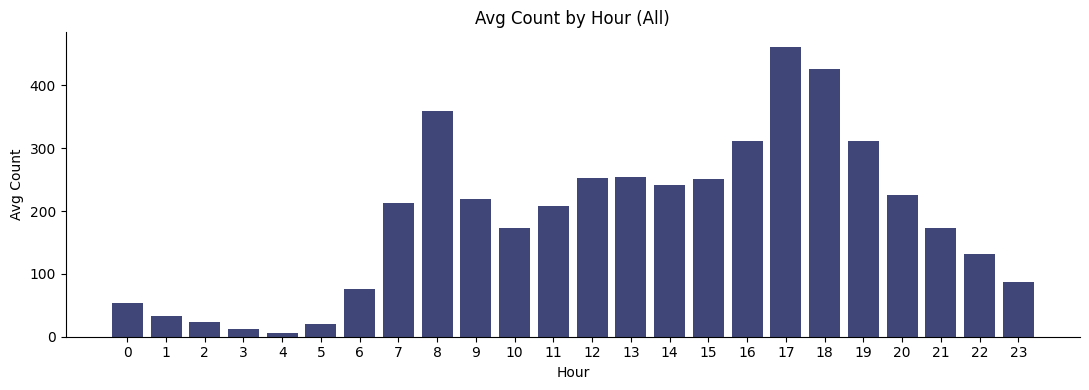

Top 5 Peak Hours:
hr
17   461.500
18   425.500
8    359.000
16   312.000
19   311.500
Name: cnt, dtype: float64


In [11]:
# 時間帯別の平均利用数を集計する
# TODO: 'hr'でグループ化し、'cnt'の平均を計算してください

hourly_avg = df.groupby("hr")["cnt"].mean()

# 棒グラフで可視化する（変更不要）
fig, ax = plt.subplots()
ax.bar(hourly_avg.index, hourly_avg.values, color='#1E2761', alpha=0.85)
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Count')
ax.set_title('Avg Count by Hour (All)')
ax.set_xticks(range(0, 24, 1))
plt.tight_layout()
plt.show()

# ピーク時間帯を確認する
print('Top 5 Peak Hours:')
print(hourly_avg.sort_values(ascending=False).head().round(1))

**🤔 判断①（この結果だけを見て答えてください）**

限られた再配置スタッフを、どの時間帯に重点配置しますか？

→ （7,8,9時と17,18時）

その理由：

→ （利用者が多いため）

---
## 分析②　平日 vs 休日

**問い**：平日と休日でパターンは違うか？

分析①では平日と休日が混在していました。分けて見るとどうなるでしょうか。

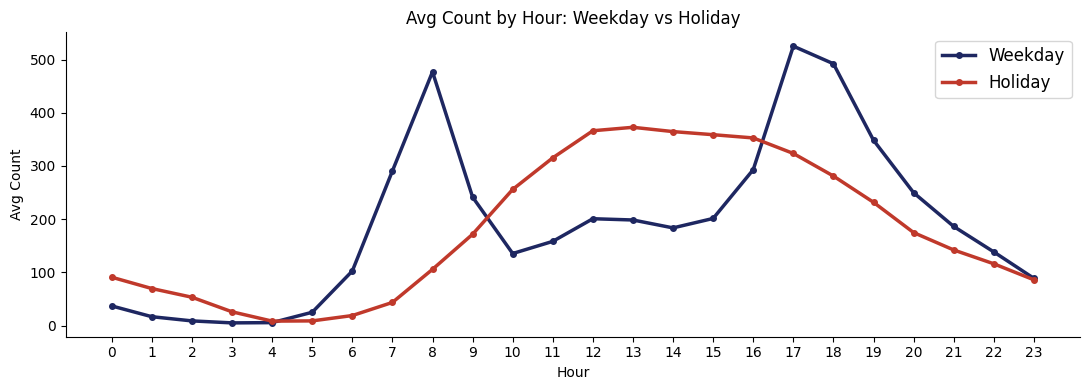

Weekday - Key Hours:
hr
7    290.600
8    477.000
12   200.800
17   525.300
18   492.200
Name: cnt, dtype: float64

Holiday - Key Hours:
hr
10   255.900
11   315.300
12   366.300
13   372.700
14   364.600
Name: cnt, dtype: float64


In [12]:
# 平日・休日別に時間帯ごとの平均利用数を計算する
# TODO: workingday=1（平日）と workingday=0（休日）をそれぞれフィルタして
#       時間帯別の平均を計算してください

weekday_avg = df[df['workingday'] == 1].groupby('hr')['cnt'].mean()
holiday_avg = df[df['workingday'] == 0].groupby('hr')['cnt'].mean()

# 折れ線グラフで比較する（変更不要）
fig, ax = plt.subplots()
ax.plot(weekday_avg.index, weekday_avg.values, label='Weekday', color='#1E2761', lw=2.5, marker='o', markersize=4)
ax.plot(holiday_avg.index, holiday_avg.values, label='Holiday', color='#C0392B', lw=2.5, marker='o', markersize=4)
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Count')
ax.set_title('Avg Count by Hour: Weekday vs Holiday')
ax.set_xticks(range(0, 24, 1))
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 主要時間帯の数値を確認する
print('Weekday - Key Hours:')
print(weekday_avg.loc[[7, 8, 12, 17, 18]].round(1))
print('\nHoliday - Key Hours:')
print(holiday_avg.loc[[10, 11, 12, 13, 14]].round(1))

**📝 分析②の気づき**

- 平日と休日でパターンはどう違うか：
- 分析①（全体）だけを見ていると何を見落とすか：
- この結果は判断①を変えるか：

---
## 分析③　登録ユーザー vs カジュアルユーザー

**問い**：誰が・いつ利用しているのか？

総需要（cnt）の内訳を、登録ユーザー（registered）とカジュアルユーザー（casual）に分けて見ます。

In [ ]:
# 平日・休日それぞれで登録/カジュアルの時間帯別平均を計算する
# TODO: 平日データ・休日データを変数に入れてください

df_weekday = df[df['workingday'] == ____]
df_holiday = df[df['workingday'] == ____]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 平日グラフ
for col, label, color in [('registered', 'Registered', '#1E2761'), ('casual', 'Casual', '#C0392B')]:
    g = df_weekday.groupby('hr')[col].mean()
    axes[0].plot(g.index, g.values, label=label, color=color, lw=2.5, marker='o', markersize=4)
axes[0].set_title('Registered vs Casual (Weekday)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Count')
axes[0].legend(fontsize=11)
axes[0].set_xticks(range(0, 24, 2))

# 休日グラフ
for col, label, color in [('registered', 'Registered', '#1E2761'), ('casual', 'Casual', '#C0392B')]:
    g = df_holiday.groupby('hr')[col].mean()
    axes[1].plot(g.index, g.values, label=label, color=color, lw=2.5, marker='o', markersize=4)
axes[1].set_title('Registered vs Casual (Holiday)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Count')
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# 数値で確認する
print('Weekday - Registered vs Casual (Key Hours):')
print(df_weekday.groupby('hr')[['registered', 'casual']].mean().loc[[7, 8, 12, 17, 18]].round(1))
print('\nHoliday - Registered vs Casual (Key Hours):')
print(df_holiday.groupby('hr')[['registered', 'casual']].mean().loc[[10, 11, 12, 13, 14]].round(1))

**🤔 判断②（分析①〜③を踏まえて）**

判断①を変更しますか？

→ （変更する／変更しない）

理由：

→ （ここに書く）

新しい判断（変更する場合）：

→ （ここに書く）

---
## 分析④　天候別の需要

**問い**：天候は需要にどれほど影響するか？

運営計画を立てる上で、天候の影響も考慮する必要があります。

In [ ]:
# 天候別の平均利用数を集計する
# TODO: 'weathersit'でグループ化し、'cnt'の平均を計算してください

weather_avg = df.groupby(____)[____].____

# 棒グラフで可視化する（変更不要）
weather_labels = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain', 4: 'Heavy Rain'}
colors = ['#1E2761', '#5B6FA6', '#C0392B', '#7B241C']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [weather_labels[i] for i in weather_avg.index],
    weather_avg.values,
    color=colors[:len(weather_avg)],
    alpha=0.85
)
for bar, val in zip(bars, weather_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', ha='center', fontsize=12)
ax.set_ylabel('Avg Count')
ax.set_title('Avg Count by Weather')
plt.tight_layout()
plt.show()

# 晴天との比較（変更不要）
base = weather_avg[1]
print('Demand by Weather (vs Clear):')
for k, v in weather_avg.items():
    print(f'  {weather_labels[k]}: {v:.0f}  (vs Clear: {v/base*100:.0f}%)')

**📝 分析④の気づき**

- 天候の影響をどう評価するか：
- 運営判断にどう活かせるか：

---
## ディスカッション準備

4つの分析を終えました。授業のディスカッション（10分）に向けて、以下の問いに答えてください。

In [ ]:
# 以下をコメントとして書いてください

# 【問い】今日の分析を踏まえて「運営資源をどう配分するか」を決めようとするとき、
#         何が言えて、何はまだ言えないか？
#
# ① 今日の分析から「言えること」
#
#    →
#
#
# ② 今日の分析だけでは「言えないこと」（判断するのに足りないもの）
#
#    →
#
#
# ③ 「言えないこと」を明らかにするには、何が必要か
#
#    →
#
#

---
## 振り返り

### 今日やったこと

| Step | 分析 | 使ったコード |
|---|---|---|
| Step 1 | データ確認 | `head()` / `info()` / `describe()` |
| 分析① | 時間帯別総需要 | `groupby('hr')['cnt'].mean()` |
| 分析② | 平日 vs 休日 | `df[df['workingday']==1]` + `groupby` |
| 分析③ | 登録 vs カジュアル | 2変数の比較 |
| 分析④ | 天候別需要 | `groupby('weathersit')` |

### 今日の核心

> 単純な記述統計でも、**問いが明確なら意思決定材料になる。**  
> しかし、**観測されたパターンから言えることと、施策の効果は別問題である。**

---

### 次回（第2回）のテーマ：意思決定から問いを立てる

**事前課題**
- BEEF+ の第2回配布資料を読む
- 「意思決定者は誰か」「何を決めるのか」「データで答えられる問いは何か」を考えてくる